# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


The first stage of sampling is a simple random sample (without replacement). Here, the model samples which individuals become infected using the following line of code:
  infected_indices = np.random.choice(
    ppl.index, # list of all person IDs
    size=int(len(ppl) * ATTACK_RATE), # calculates the number infected, 1000*0.1 = 100
    replace=False # same person cannot be selected twice
    )
Here, the sample size is determned by multiplying the total number of individuals by the ATTACK_rate. 1000 * 0.10 = 100 individuals are sampled. These individuals are sampled randomly (as per np.random.choice() function)  without replacement so the same person cannote be selected twice.


The second stage of sampling occurs during the primary contact tracing. Here, there is a repeated binary success/failure like a binomial distribution, outlined in the following code:
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS
Here, the sampling frame is the 100 infected individuals. Tbe code above generates 100 random numbers between 0 and 1. Each infected individual has a 20% chance of being traced since TRACE_SUCCESS = 0.20. If the random number is less than 0.20, then the person is assigned traced = True, else traced = False. This is the repeated binary success/failure process.


The third stage of sampling occurs during the secondary tracing outlined in the following code:
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True
Here, this marks all infected individuals from the selected event type as traced. This is not simple random sampling because the selection depends on whether the event type reaches the tracing threshold. Then we see a group-level tracing since individuals are traced based on membership in an event group rather than than only by independent individual selection. This appears to me to be a non-probability survey sample, but it doesnt correspond to any of the methods discussed in lecture (convenience, quota, purposive, or snowball). Once the event type is flagged, all individuals infected from that group become traced, which intriduces unequal invlusion probabilities across the group.


Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

When I changed the simulation repetitions from 1000 to 10 and reran the code multiple times, the outputted histograms changed quite substantially between the runs. In some runs, the distributions appeared to be more spread out. The overlap between the blue (infections from wedding) and the red (traced to wedding) histograms also changed considerably between the runs. These disparities happen bevause only 10  outbreaks are being generated and with such a small number of repetitions, random variations have a large effect on the final histogram. Each time the code runs, different individuals are randomly infected and different infected individuals are randomly traced, and different event types may cross the secondary tracing threshold leading to unstable graphs. Additionally, we can conclude that the outputs therefore have low reproducibility when using only 10 repetitions. As such, increasing the number of repetitions should improve these parameters. 

When I changed the simulation repetitions to 100 and reran the code multiple times the outputs are much more stable. Here, obviously, we have 100 values in the histogram instead of just 10. The histograms look smoother and more bell-shaped with more consistent overlap between blue and red despire the slight changes between runs. The reproducibility is much better than when there were only 10 repetitions but it is still not perfect. However, even with the 100 repetitions, I can see that the red traced distribution is typically wider.

The above explanations is related to the Law of Large Numbers discussed in lecture. However, increasing repetitions does not guarantee identical results despite a clear improvement in stability with reruns.

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The script needs to produce the same output when run multiple times.

On line 86 of the code in the below cell, I added:
np.random.seed(123)

This line is just before running the simulation repetitions to make the random number generation reproducible. 

Beofre adding the seed line described above, the code produced different graphs each time it ran bevause of the following functions:
np.random.choice()
no.random.rand()

These functions generated new randomvalues every time and importantly, they control which individuals become infected and which are traced.

With the seed, the random number generator starts from the same point each time the script is run - meaning the same individuals are slected and infected and the same traing outcomes occur - thereby producing the same histogram each time. 

## Code

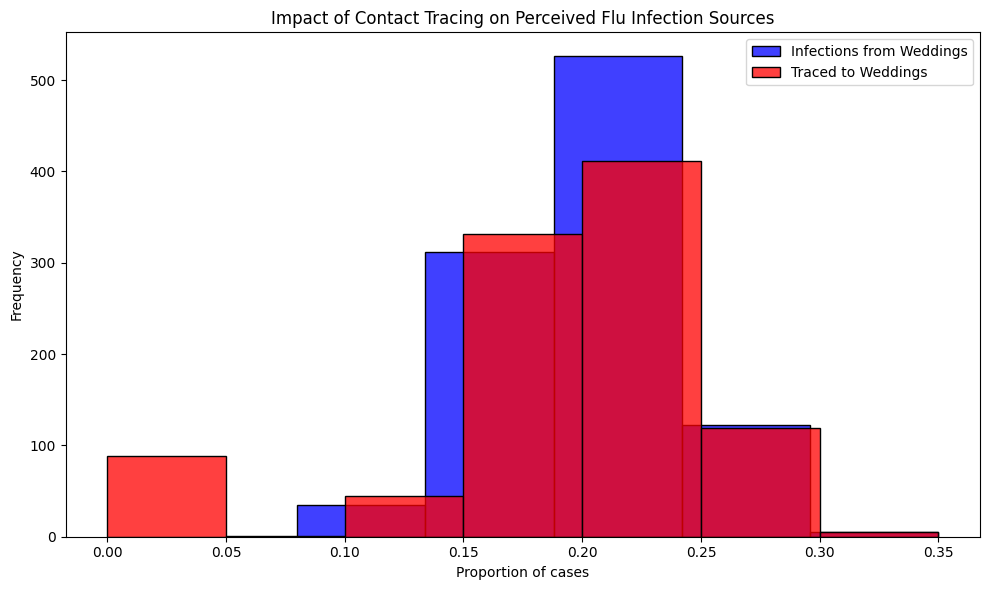

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10 # 10% of people became infected
TRACE_SUCCESS = 0.20 # each infected person has a 20% chance of being traced
SECONDARY_TRACE_THRESHOLD = 2 # if at least 2 traced infected people are found from an event type, then secondary tracing is created

def simulate_event(m):
  """
  Simulates the infection and tracing process for a series of events.
  
  This function creates a DataFrame representing individuals attending weddings and brunches,
  infects a subset of them based on the ATTACK_RATE, performs primary and secondary contact tracing,
  and calculates the proportions of infections and traced cases that are attributed to weddings.
  
  Parameters:
  - m: Dummy parameter for iteration purposes.
  
  Returns:
  - A tuple containing the proportion of infections and the proportion of traced cases
    that are attributed to weddings.
  """
  # Create DataFrame for people at events with initial infection and traced status
  # nobody is infected yet, nobody is traced yet
  events = ['wedding'] * 200 + ['brunch'] * 800 # list of 1000 people, 200 attending wedding, 800 attending brunch
  ppl = pd.DataFrame({
      'event': events, # whether person attends wedding or brunch
      'infected': False, # starts as false
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype()) # note: non-infected people are not traced yet

  # Infect a random subset of people -- FIRST MAJOR SAMPLING STAGE
  # Randomly choose 100 unique people from the 1000 person population - simple random sampling without replacement
  infected_indices = np.random.choice(
    ppl.index, # list of all person IDs
    size=int(len(ppl) * ATTACK_RATE), # calculates the number infected, 1000*0.1 = 100
    replace=False # same person cannot be selected twice
    )
  
  # Mark those 100 selected people as infected
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  # Second major sampling stage
  # Selecting only the infected people, count them (100) and generate 100 random numbers between 0 and 1
  # if the assignment is < 0.2, and they were infected people, they will be assigned a True tracing result. If that number was > 0.2 for infected people, they will be assigned a False tracing result
  # SO - infected people become True of False for traced, non-infected stay NaN
  # a binomial - repeated success/failure trials with probability p
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  # Secondary contact tracing based on event attendance (event/group tracing)
  # not random anymore, once passed a threshold, all infected people become traced
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts() # counts how many traced infected people came from each event type
  # did any event type have at least 2 traced infected people
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index # this keeps only event types with at least 2 traced cases
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True # for any event that crossed the threshold, mark all infected people from that event type as traced

  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w')) # infected wedding people
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b')) # infected brunch people
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections) # proportion of infected people from weddings -- The TRUE value

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w')) # infected, traced wedding people
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b')) # infected, traced brunch people
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces) # among traced infections, what proportion come from weddings

  return p_wedding_infections, p_wedding_traces # 1. True wedding infection proportion, 2. traced wedding infection proportion

# Run the simulation 1000 times
np.random.seed(123) # make the random number generation reproducible.
results = [simulate_event(m) for m in range(1000)] # runs 1000 different fake outbreaks - infecting different people, tracing different people
# results = [simulate_event(m) for m in range(10)]
# results = [simulate_event(m) for m in range(100)]

props_df = pd.DataFrame(results, columns=["Infections", "Traces"]) # results table

# Plotting the results
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()

## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 02 February 2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [ ] Create a branch called `assignment-1`.
- [ ] Ensure that the repository is public.
- [ ] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
